In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [2]:
data = {
    "Date":pd.date_range('2024-01-01',periods=36,freq='ME'),
    'Sales': [
        120,125,123,130,135,140,
        138,145,150,148,155,160,
        165,170,168,175,180,185,
        190,188,195,200,205,210,
        208,215,220,225,223,230,
        235,240,245,250,248,255
    ]
}

df = pd.DataFrame(data)
df.set_index('Date',inplace=True)

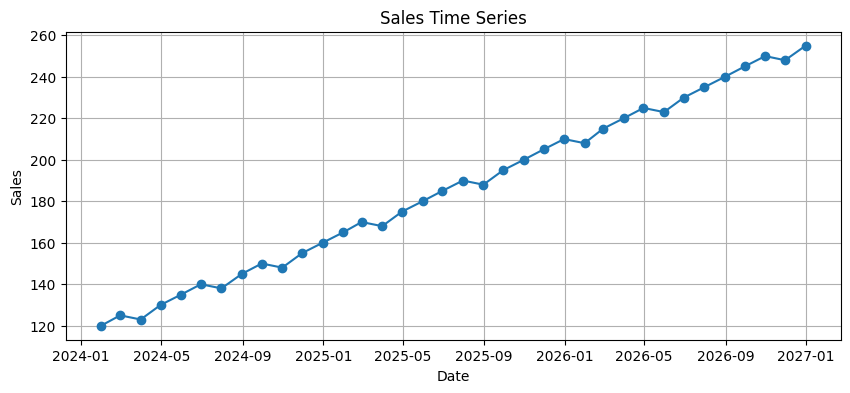

In [4]:
plt.figure(figsize=(10,4))

plt.plot(df['Sales'],marker='o')

plt.title('Sales Time Series')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.grid(True)

plt.show()

In [5]:
model = ARIMA(df['Sales'], order=(1,1,1))

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [6]:
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [7]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -93.750
Date:                Thu, 16 Jul 2026   AIC                            193.499
Time:                        20:47:11   BIC                            198.165
Sample:                    01-31-2024   HQIC                           195.110
                         - 12-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.019     52.883      0.000       0.963       1.037
ma.L1         -0.9958      5.770     -0.173      0.863     -12.304      10.313
sigma2        11.1746     65.698      0.170      0.8

In [10]:
forcast = model_fit.forecast(steps=6)

print(forcast)

2027-01-31    258.774661
2027-02-28    262.549296
2027-03-31    266.323905
2027-04-30    270.098487
2027-05-31    273.873043
2027-06-30    277.647574
Freq: ME, Name: predicted_mean, dtype: float64


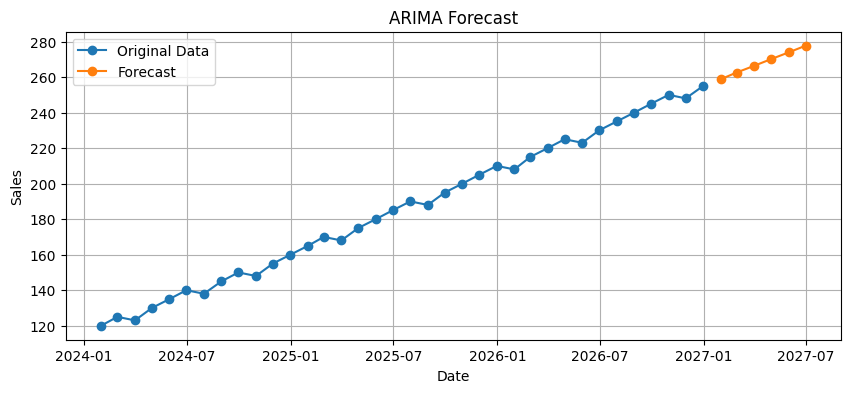

In [11]:
plt.figure(figsize=(10,4))

plt.plot(df["Sales"], label="Original Data", marker="o")

plt.plot(forcast, label="Forecast", marker="o")

plt.title("ARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# Project 2

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
data = {
    "Date": pd.date_range("2024-01-01", periods=36, freq="ME"),
    "Sales": [
        120,125,123,130,135,140,
        138,145,150,148,155,160,
        165,170,168,175,180,185,
        190,188,195,200,205,210,
        208,215,220,225,223,230,
        235,240,245,250,248,255
    ]
}

df = pd.DataFrame(data)

df.set_index("Date", inplace=True)